# Day 08. Exercise 05
# Clustering

## 0. Imports

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

warnings.filterwarnings('ignore')
pd.options.display.max_rows = 10

## 1. Preprocessing

1. Read the file [`regression.csv`](https://drive.google.com/file/d/1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma/view?usp=sharing) to a dataframe.
2. Remove the `pageviews`, we will cluster the users only by the number of the commits and their average difference.

In [2]:
df = pd.read_csv('../data/regression.csv')
df.drop('pageviews', axis=1, inplace=True)
df

,uid,num_commits,AVG(diff)
0,user_1,62,-64.400000
1,user_10,20,-74.800000
2,user_14,61,-159.000000
3,user_17,51,-61.600000
4,user_18,5,-5.666667
...,...,...,...
24,user_31,128,-104.750000
25,user_4,40,-175.600000
26,user_6,15,-62.600000
27,user_7,8,-115.500000


In [3]:
X = df[['num_commits', 'AVG(diff)']]

## 2. KMeans

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters, use `random_state=21` and `n_clusters=3`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `n_clusters` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

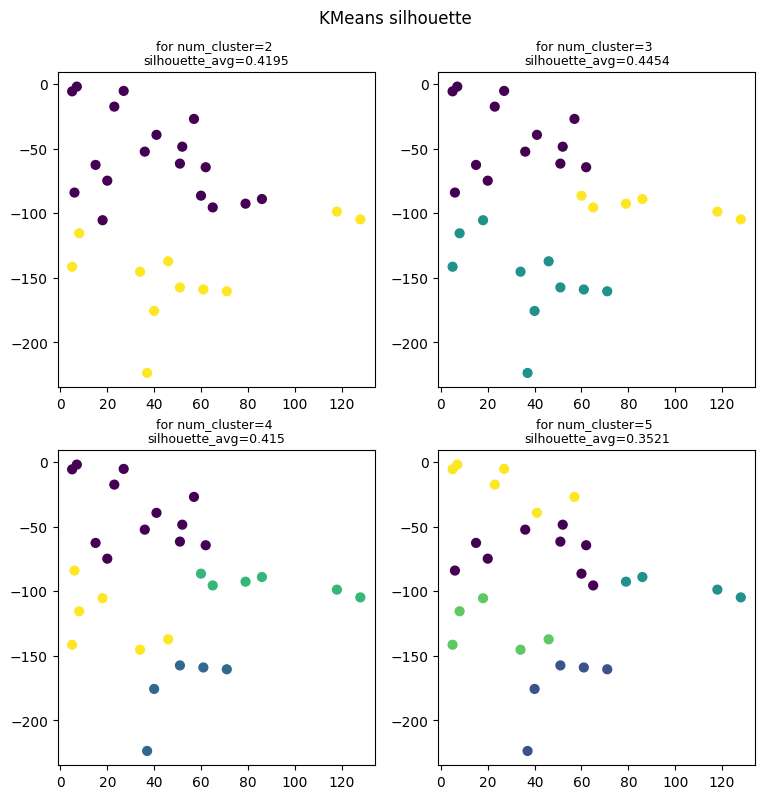

In [4]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(9, 9))
for num_cluster, ax_val in enumerate([(0, 0), (0, 1), (1, 0), (1, 1)], 2):
    y_pred  = KMeans(n_clusters=num_cluster, random_state=21, n_init="auto").fit_predict(X)
    ax[ax_val].scatter(X['num_commits'], X['AVG(diff)'], c=y_pred, s=40)
    silhouette_avg = round(float(silhouette_score(X, y_pred)), 4)
    ax[ax_val].set_title(f"for {num_cluster=} \n{silhouette_avg=}", fontdict={'fontsize': 9})
plt.suptitle("KMeans silhouette").set_y(0.95)

## 3. DBSCAN

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters with `eps=20` and `min_samples=2`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `eps` and `min_samples` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

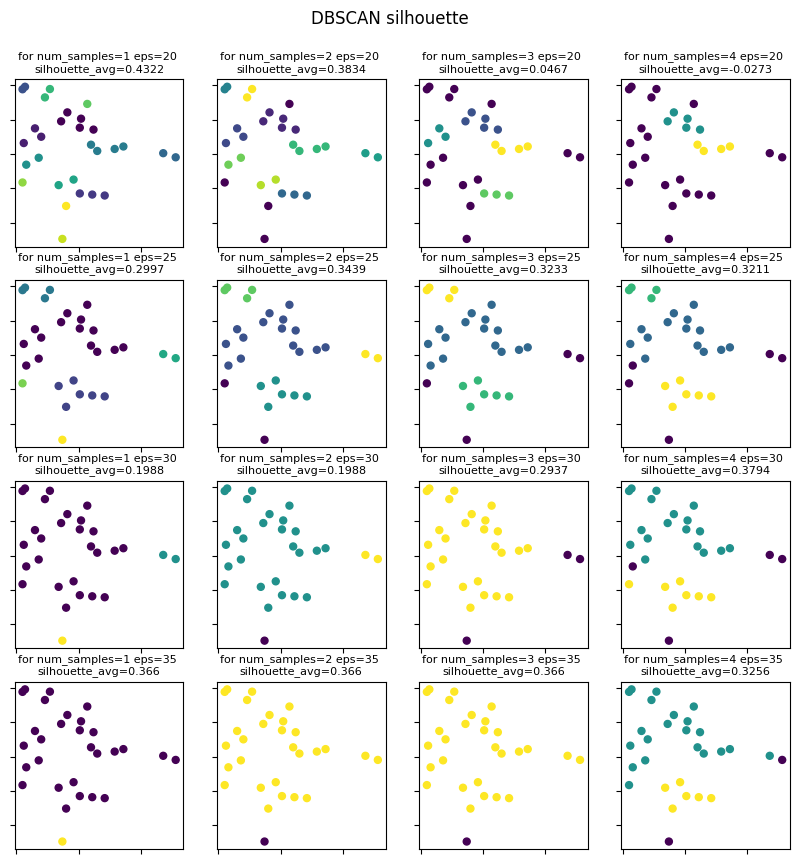

In [5]:
fig, ax = plt.subplots(nrows=4, ncols=4, figsize=(10, 10))
eps = 15
for ax_y in range(4):
    eps += 5
    for num_samples, ax_x in enumerate(range(4), 1):
        y_pred  = DBSCAN(eps=eps, min_samples=num_samples).fit_predict(X)
        ax[ax_y, ax_x].scatter(X['num_commits'], X['AVG(diff)'], c=y_pred, s=25)
        silhouette_avg = round(float(silhouette_score(X, y_pred)), 4)
        ax[ax_y, ax_x].set_title(f"for {num_samples=} {eps=} \n{silhouette_avg=}", fontdict={'fontsize': 8})
        ax[ax_y, ax_x].set_xticklabels([])
        ax[ax_y, ax_x].set_yticklabels([])
plt.suptitle("DBSCAN silhouette").set_y(0.95)

## 4. Hierarchical (AgglomerativeClustering)

1. Use this algorithm to create clusters with `n_clusters=5`.
2. Visualize the data on a `scatter plot`.
3. Try different values of `n_clusters` and see how your plot will change.
4. Calculate the `silhouette_score`.
5. Visualize the `dendrogram`.

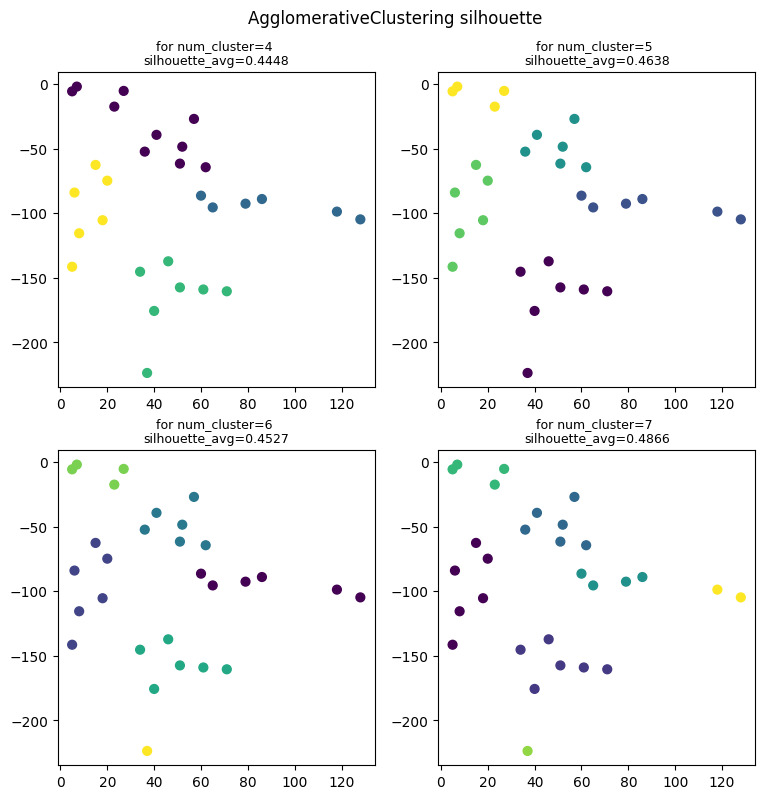

In [6]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(9, 9))
for num_cluster, ax_val in enumerate([(0, 0), (0, 1), (1, 0), (1, 1)], 4):
    y_pred  = AgglomerativeClustering(n_clusters=num_cluster).fit_predict(X)
    ax[ax_val].scatter(X['num_commits'], X['AVG(diff)'], c=y_pred, s=40)
    silhouette_avg = round(float(silhouette_score(X, y_pred)), 4)
    ax[ax_val].set_title(f"for {num_cluster=} \n{silhouette_avg=}", fontdict={'fontsize': 9})
plt.suptitle("AgglomerativeClustering silhouette").set_y(0.95)

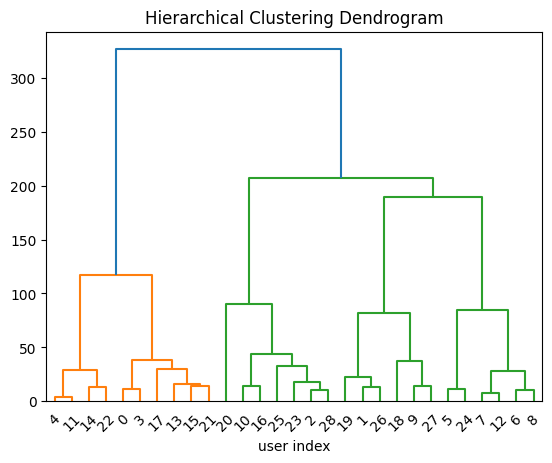

In [7]:
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram
    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)


# setting distance_threshold=0 ensures we compute the full tree.
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
model = model.fit(X)

plt.title("Hierarchical Clustering Dendrogram")
plot_dendrogram(model, truncate_mode="level", p=6)
plt.xlabel("user index")
plt.show()

## 5. Function

Write a function that:
1. Takes as arguments: model class of clustering, its parameters, the name of the parameter for optimization, the range of the parameter values to try.
2. Tries different values from the given parameter range and calculates the `silhouette_score` for each value from the range.
3. Finds out the best value for the parameter in the range.
4. Returns two subplots:


- - the first shows how the `silhouette_score` changes depending on the value of the parameter,
- - the second visualizes the data on a `scatter plot` using the clustering model with the best value of the parameter.

In [8]:
def best_silhouette(model, param, params_range,  X, common_params=None,) -> None:
    best = (0, 0); sil_scores = []
    for param_val in params_range:
        
        if common_params:
             y_pred = model(**{param: param_val, **common_params}).fit_predict(X)
        else:
            y_pred = model(**{param: param_val}).fit_predict(X)
            
        silhouette_avg = round(float(silhouette_score(X, y_pred)), 4)
        sil_scores.append(silhouette_avg)
        best = (param_val, silhouette_avg, y_pred) if silhouette_avg > best[1] else best

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
    to_plot = pd.DataFrame({'silhouette_score': sil_scores, 'param_vals': params_range})

    sns.scatterplot(data= X, x='num_commits', y='AVG(diff)', c=best[2], s=50, ax=ax[0])
    sns.regplot(data=to_plot, x="silhouette_score", y="param_vals", ci=25, ax=ax[1], logx=True)

    plt.suptitle(f'Function: cluster data and silhouette score depending on parameter value\n{model.__name__=}')
    plt.show()

    print(f'Parameter - {param}, best={best[0]}, silhouette score={best[1]}')

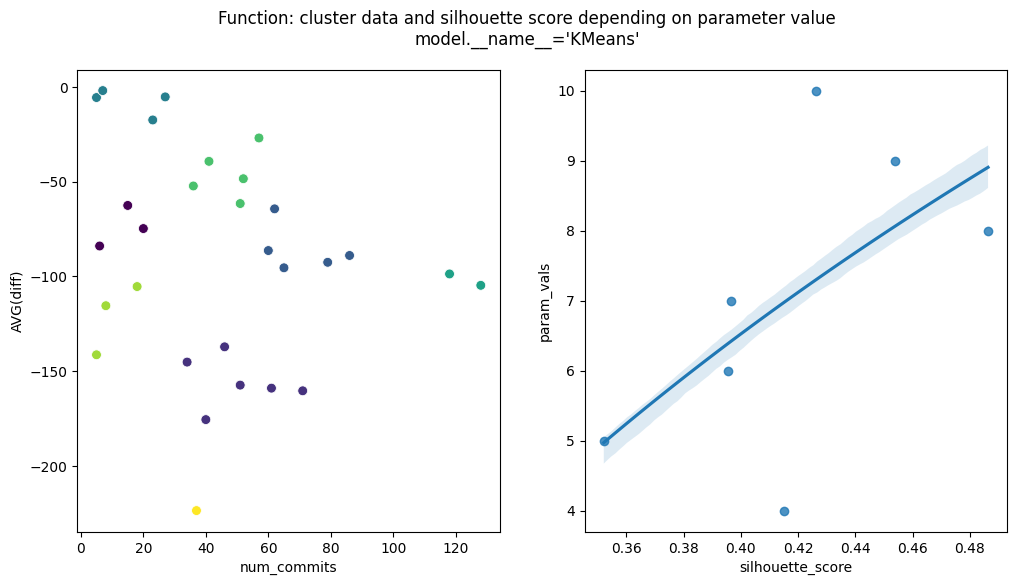

Parameter - n_clusters, best=8, silhouette score=0.4864


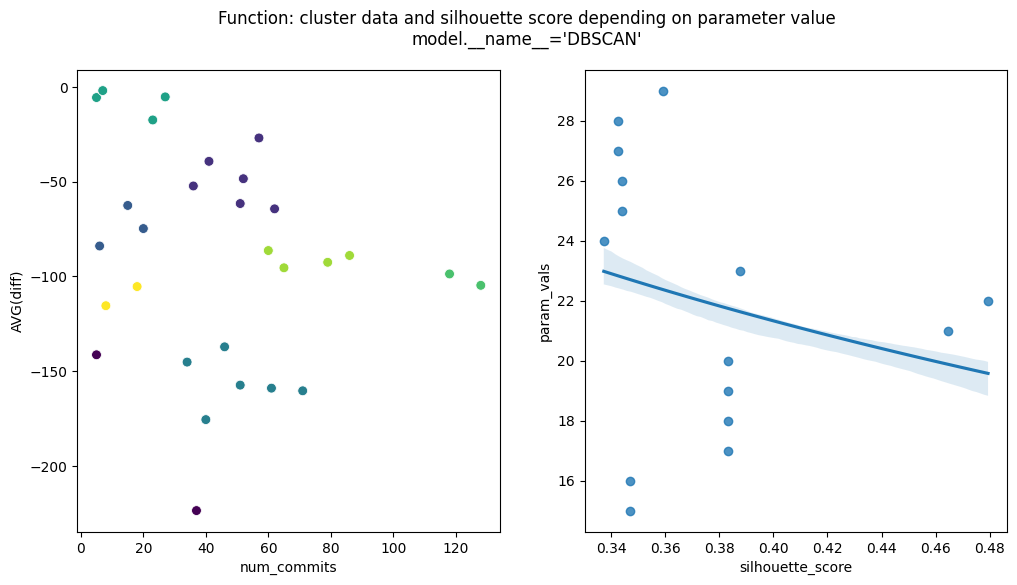

Parameter - eps, best=22, silhouette score=0.4794


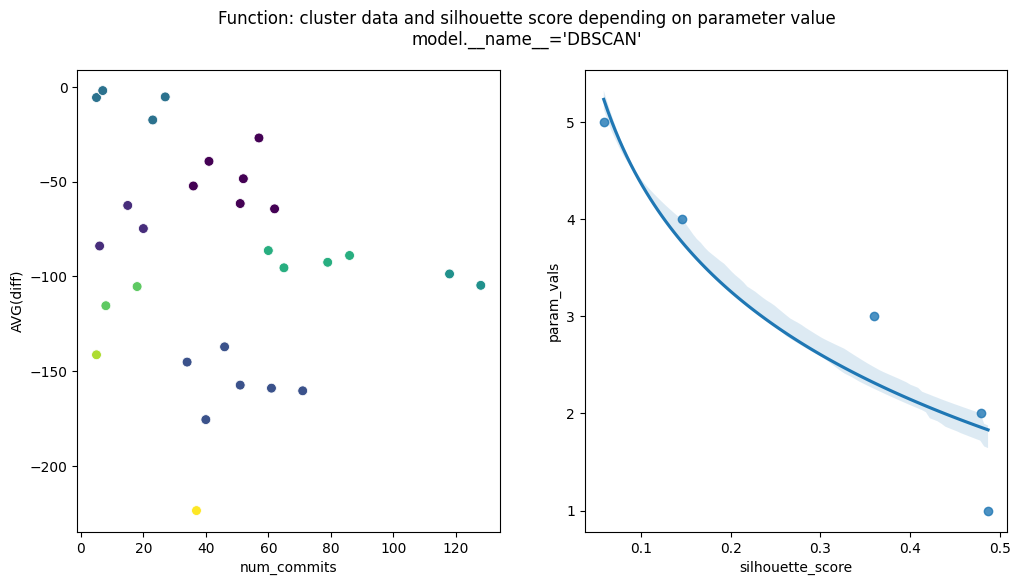

Parameter - min_samples, best=1, silhouette score=0.4871


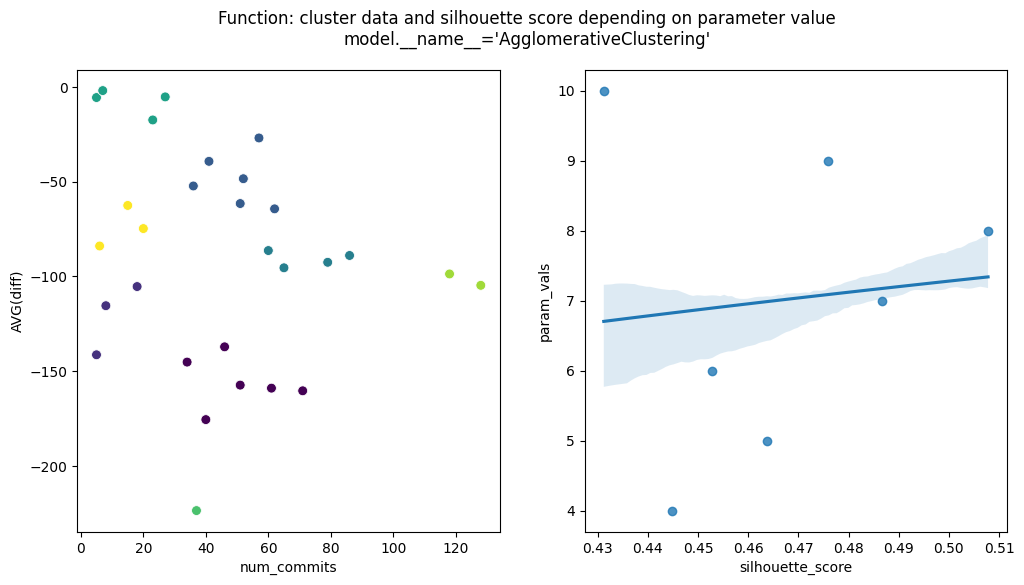

Parameter - n_clusters, best=8, silhouette score=0.5078


In [9]:
best_silhouette(model=KMeans, param='n_clusters', params_range=range(4, 11), common_params={'random_state': 21, 'n_init':"auto"}, X=X)
best_silhouette(model=DBSCAN, param='eps', params_range=range(15, 30), common_params={'min_samples': 2}, X=X)
best_silhouette(model=DBSCAN, param='min_samples', params_range=range(1, 6), common_params={'eps': 22}, X=X)
best_silhouette(model=AgglomerativeClustering, param='n_clusters', params_range=range(4, 11), X=X)